# Задача №3: ML/DL методы прогнозирования и выявление аномалий

**Цель:** Обоснованный выбор и сравнение методов машинного обучения и глубокого обучения для прогнозирования температуры в Дели, а также выявление аномалий во временном ряду.

| Блок | Методы |
|------|--------|
| **ML** (`mlforecast`) | LightGBM, XGBoost, Ridge Regression |
| **DL** (`neuralforecast`) | NHITS, NBEATS, LSTM |
| **Аномалии** | IQR, Isolation Forest, DBSCAN |

**Бейзлайн** (из Задачи №2): MSTL — MAE=2.05°C, RMSE=2.42°C  
**Горизонт прогноза:** 30 дней  
**Валидация:** Бектестинг, 3 скользящих окна (аналогично Задаче №2)

## 0. Установка зависимостей

In [145]:
# !pip install mlforecast lightgbm xgboost scikit-learn -q
# !pip install neuralforecast -q

## 1. Импорт библиотек

In [146]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ML
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from window_ops.rolling import rolling_mean, rolling_std, rolling_min, rolling_max
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# DL
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, LSTM
from neuralforecast.losses.pytorch import MAE as NF_MAE

# Аномалии
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

HORIZON = 30
N_WINDOWS = 3
SEASON_LENGTH = 365
SEED = 42


## 2. Загрузка данных

In [147]:
# Загрузка подготовленных данных из Задачи №1
df_raw = pd.read_csv('Delhi_Climate_Final.csv', parse_dates=['date'], index_col='date')

# Формат StatsForecast / MLForecast / NeuralForecast: unique_id, ds, y
df_sf = df_raw.reset_index()[['date', 'meantemp']].copy()
df_sf.columns = ['ds', 'y']
df_sf['unique_id'] = 'Delhi_Temperature'
df_sf = df_sf[['unique_id', 'ds', 'y']]

# Train / Test
df_train = df_sf.iloc[:-HORIZON].copy()
df_test  = df_sf.iloc[-HORIZON:].copy()

print(f'Train: {df_train["ds"].min().date()} → {df_train["ds"].max().date()} ({len(df_train)} наблюдений)')
print(f'Test:  {df_test["ds"].min().date()} → {df_test["ds"].max().date()} ({len(df_test)} наблюдений)')

Train: 2013-01-01 → 2017-03-25 (1545 наблюдений)
Test:  2017-03-26 → 2017-04-24 (30 наблюдений)


---
# БЛОК 1: Выявление аномалий

Аномалии ищем **на обучающем ряду** до обучения прогностических моделей.  
Используем три принципиально разных подхода:

| Метод | Принцип | Тип |
|-------|---------|-----|
| **IQR** | Статистический: выброс за пределы [Q1-1.5×IQR, Q3+1.5×IQR] | Univariate, без обучения |
| **Isolation Forest** | Случайная изоляция точки деревьями решений | ML, без учителя |
| **DBSCAN** | Кластеризация по плотности; точки вне кластеров — аномалии | ML, без учителя |

### 3.1 Метод IQR (Interquartile Range)

IQR границы: [-0.44°C, 50.06°C]
Обнаружено аномалий IQR: 0
Series([], Name: y, dtype: float64)


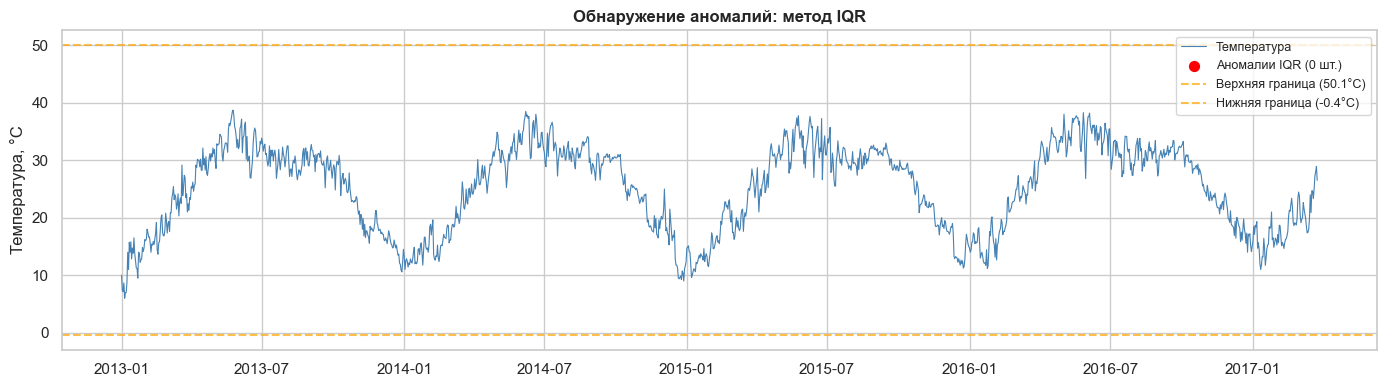

In [148]:
series = df_train.set_index('ds')['y']

Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

anomalies_iqr = series[(series < lower_iqr) | (series > upper_iqr)]

print(f'IQR границы: [{lower_iqr:.2f}°C, {upper_iqr:.2f}°C]')
print(f'Обнаружено аномалий IQR: {len(anomalies_iqr)}')
print(anomalies_iqr)

plt.figure(figsize=(14, 4))
plt.plot(series, color='steelblue', linewidth=0.8, label='Температура')
plt.scatter(anomalies_iqr.index, anomalies_iqr.values,
            color='red', zorder=5, s=50, label=f'Аномалии IQR ({len(anomalies_iqr)} шт.)')
plt.axhline(upper_iqr, color='orange', linestyle='--', alpha=0.7, label=f'Верхняя граница ({upper_iqr:.1f}°C)')
plt.axhline(lower_iqr, color='orange', linestyle='--', alpha=0.7, label=f'Нижняя граница ({lower_iqr:.1f}°C)')
plt.title('Обнаружение аномалий: метод IQR', fontweight='bold')
plt.ylabel('Температура, °C')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Isolation Forest

**Обоснование параметров:**  
- `contamination=0.03` — ожидаем ~3% аномалий в ряду (согласно EDA из Задачи №1)  
- `n_estimators=200` — достаточно для стабильной оценки на ряду длиной ~1500 наблюдений  
- Признаки: `y` (температура) + лаговые признаки lag-1, lag-7, lag-30 для учёта контекста

Isolation Forest: обнаружено аномалий: 46
Даты аномалий: ['2013-05-24', '2013-05-25', '2013-05-26', '2013-05-27', '2013-06-23', '2013-12-29', '2014-06-08', '2014-06-09', '2014-06-10', '2014-06-11', '2014-06-12', '2014-06-21', '2014-07-11', '2014-12-21', '2014-12-22', '2014-12-23', '2014-12-24', '2014-12-25', '2014-12-26', '2014-12-27', '2014-12-28', '2014-12-29', '2014-12-30', '2014-12-31', '2015-01-01', '2015-01-02', '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-10', '2015-01-12', '2015-01-13', '2015-01-14', '2015-01-16', '2015-01-21', '2015-01-29', '2016-05-17', '2016-05-18', '2016-05-19', '2016-05-20', '2016-05-21', '2016-05-22', '2016-05-23', '2016-05-27', '2016-06-03', '2016-06-11']


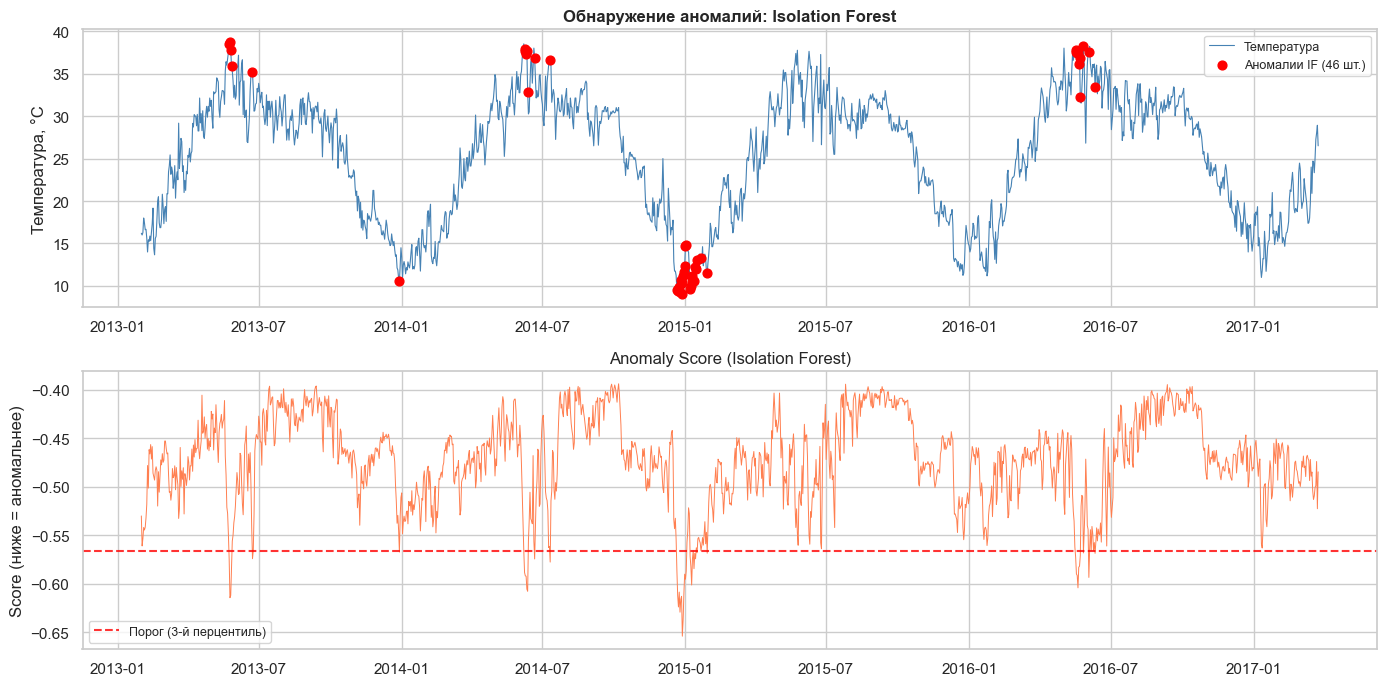

In [149]:
# Формируем признаки для Isolation Forest
df_if = df_train[['ds', 'y']].copy().set_index('ds')
df_if['lag_1']  = df_if['y'].shift(1)
df_if['lag_7']  = df_if['y'].shift(7)
df_if['lag_30'] = df_if['y'].shift(30)
df_if['rolling_mean_7'] = df_if['y'].rolling(7).mean()
df_if = df_if.dropna()

scaler = StandardScaler()
X_if = scaler.fit_transform(df_if)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # Ожидаемая доля аномалий
    random_state=SEED
)
labels_if = iso_forest.fit_predict(X_if)  # -1 = аномалия, 1 = норма
scores_if = iso_forest.score_samples(X_if)  # Чем меньше — тем аномальнее

anomalies_if_idx = df_if.index[labels_if == -1]
print(f'Isolation Forest: обнаружено аномалий: {len(anomalies_if_idx)}')
print(f'Даты аномалий: {list(anomalies_if_idx.strftime("%Y-%m-%d"))}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Верхний: ряд с аномалиями
axes[0].plot(df_if.index, df_if['y'], color='steelblue', linewidth=0.8, label='Температура')
axes[0].scatter(anomalies_if_idx, df_if.loc[anomalies_if_idx, 'y'],
                color='red', s=40, zorder=5, label=f'Аномалии IF ({len(anomalies_if_idx)} шт.)')
axes[0].set_title('Обнаружение аномалий: Isolation Forest', fontweight='bold')
axes[0].set_ylabel('Температура, °C')
axes[0].legend(fontsize=9)

# Нижний: anomaly score
axes[1].plot(df_if.index, scores_if, color='coral', linewidth=0.7)
threshold = np.percentile(scores_if, 3)
axes[1].axhline(threshold, color='red', linestyle='--', alpha=0.8, label=f'Порог (3-й перцентиль)')
axes[1].set_title('Anomaly Score (Isolation Forest)')
axes[1].set_ylabel('Score (ниже = аномальнее)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.3 DBSCAN

**Обоснование параметров:**  
- `eps=1.5` — радиус окрестности в пространстве стандартизированных признаков; подобран по k-distance графику  
- `min_samples=5` — минимальный размер кластера; защищает от пометки редких, но реальных значений как аномалий  
- Признаки: скользящее среднее за 7 дней + отклонение от него (z-score)

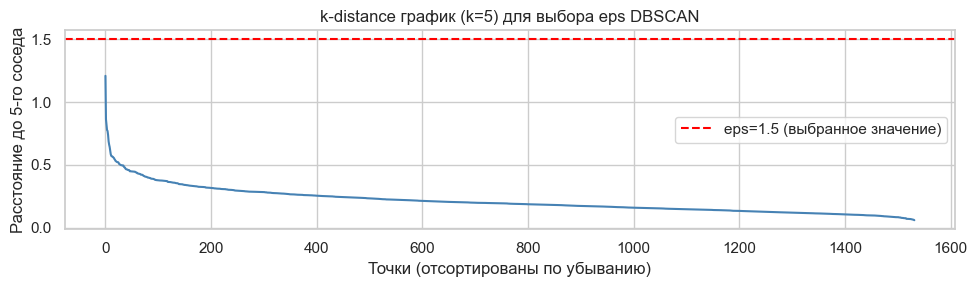

In [150]:
# k-distance plot для выбора eps
from sklearn.neighbors import NearestNeighbors

df_db = df_train[['ds', 'y']].copy().set_index('ds')
df_db['rolling_mean_14'] = df_db['y'].rolling(14).mean()
df_db['deviation']       = df_db['y'] - df_db['rolling_mean_14']
df_db['lag_1']           = df_db['y'].shift(1)
df_db = df_db.dropna()

scaler_db = StandardScaler()
X_db = scaler_db.fit_transform(df_db)

# k-distance (k=5) для подбора eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 3))
plt.plot(k_dist, color='steelblue')
plt.axhline(1.5, color='red', linestyle='--', label='eps=1.5 (выбранное значение)')
plt.title('k-distance график (k=5) для выбора eps DBSCAN')
plt.xlabel('Точки (отсортированы по убыванию)')
plt.ylabel('Расстояние до 5-го соседа')
plt.legend()
plt.tight_layout()
plt.show()

DBSCAN: количество кластеров: 1
DBSCAN: обнаружено аномалий: 0


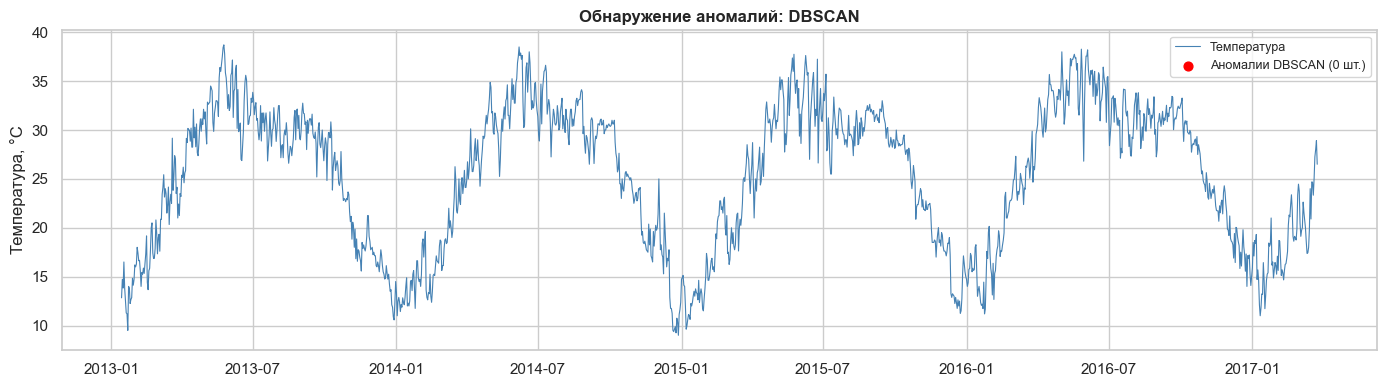

In [151]:
# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_db)

# Метка -1 = шум (аномалия)
anomalies_db_idx = df_db.index[labels_db == -1]
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

print(f'DBSCAN: количество кластеров: {n_clusters}')
print(f'DBSCAN: обнаружено аномалий: {len(anomalies_db_idx)}')

plt.figure(figsize=(14, 4))
plt.plot(df_db.index, df_db['y'], color='steelblue', linewidth=0.8, label='Температура')
plt.scatter(anomalies_db_idx, df_db.loc[anomalies_db_idx, 'y'],
            color='red', s=40, zorder=5, label=f'Аномалии DBSCAN ({len(anomalies_db_idx)} шт.)')
plt.title('Обнаружение аномалий: DBSCAN', fontweight='bold')
plt.ylabel('Температура, °C')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.4 Сравнение методов выявления аномалий

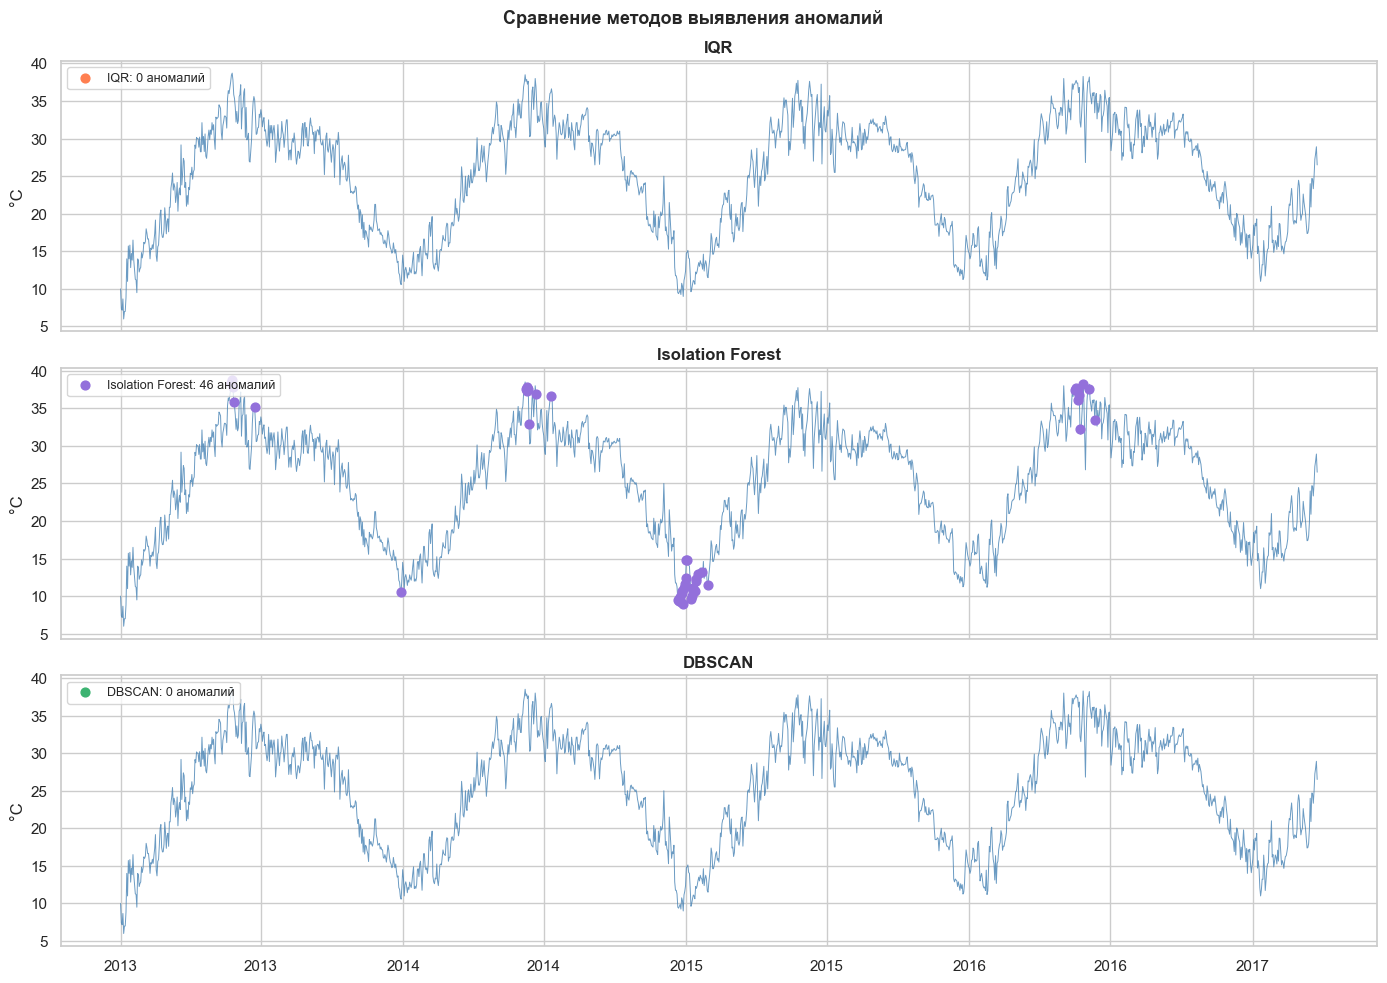

Аномалии, найденные ≥ 2 методами (IQR ∩ IF): 0
[]

Сводка:
  IQR:              0 аномалий
  Isolation Forest: 46 аномалий
  DBSCAN:           0 аномалий


In [152]:
# Совмещённый график всех трёх методов
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

methods = [
    ('IQR', anomalies_iqr.index, 'coral'),
    ('Isolation Forest', anomalies_if_idx, 'mediumpurple'),
    ('DBSCAN', anomalies_db_idx, 'mediumseagreen'),
]

for ax, (name, idx, color) in zip(axes, methods):
    ax.plot(series.index, series.values, color='steelblue', linewidth=0.7, alpha=0.8)
    ax.scatter(idx, series.reindex(idx),
               color=color, s=40, zorder=5, label=f'{name}: {len(idx)} аномалий')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('°C')
    ax.legend(fontsize=9, loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Сравнение методов выявления аномалий', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Пересечение — аномалии найденные несколькими методами
set_iqr = set(anomalies_iqr.index)
set_if  = set(anomalies_if_idx)
set_db  = set(anomalies_db_idx)

consensus = set_iqr & set_if  # Совпадают ≥ 2 методов
print(f'Аномалии, найденные ≥ 2 методами (IQR ∩ IF): {len(consensus)}')
print(sorted(consensus))

print(f'\nСводка:')
print(f'  IQR:              {len(set_iqr)} аномалий')
print(f'  Isolation Forest: {len(set_if)} аномалий')
print(f'  DBSCAN:           {len(set_db)} аномалий')

---
# БЛОК 2: ML-методы прогнозирования (mlforecast)

### Feature Engineering для временных рядов

MLForecast автоматически создаёт признаки на основе:
- **Лаговых переменных** (`lags`): значения ряда на шагах t-1, t-7, t-14, t-30, t-365
- **Скользящих статистик** (`lag_transforms`): среднее, стандартное отклонение, мин/макс за 7, 14, 30 дней
- **Календарных признаков** (`date_features`): день недели, месяц, день года

**Обоснование лагов:**
- `lag_1` — вчерашняя температура (сильная автокорреляция)
- `lag_7` — температура неделю назад (недельный паттерн)
- `lag_30` — температура месяц назад (сезонный контекст)
- `lag_365` — температура год назад (годовой цикл, аналог SeasonalNaive)

In [153]:
# Модели
ml_models = [
    lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED,
        verbosity=-1
    ),
    XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=10,
        random_state=SEED,
        verbosity=0
    ),
    Ridge(alpha=1.0),
]

mlf = MLForecast(
    models=ml_models,
    freq='D',
    # Берём разность ряда: убирает нестационарность (d=1 из ADF-теста Задачи №2)
    target_transforms=[Differences([1])],
    lags=[1,2,3,4,5,6,7,14,21,28,30,60,90,180,365],
    lag_transforms={
    7:  [(rolling_mean, 7), (rolling_std, 7), (rolling_min, 7), (rolling_max, 7)],
    14: [(rolling_mean, 14), (rolling_std, 14)],
    30: [(rolling_mean, 30), (rolling_std, 30)],
    90: [(rolling_mean, 90)],
},
    date_features=[
    'dayofweek',
    'month',
    'dayofyear',
    'week',
    'quarter',
    'is_month_start',
    'is_month_end'
],
)

print('MLForecast инициализирован. Модели:')
for m in ml_models:
    print(f'  - {m.__class__.__name__}')

MLForecast инициализирован. Модели:
  - LGBMRegressor
  - XGBRegressor
  - Ridge


### 4.1 Бектестинг ML-моделей

In [154]:
# Кросс-валидация ML
cv_ml = mlf.cross_validation(
    df=df_train,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=False,   # Не переобучать на каждом окне — ускоряет вычисления
)

print(f'CV результат: {cv_ml.shape}')
cv_ml.head()

CV результат: (90, 7)


,unique_id,ds,cutoff,y,LGBMRegressor,XGBRegressor,Ridge
0,Delhi_Temperature,2016-12-26,2016-12-25,17.142857,15.196417,14.448217,15.008431
1,Delhi_Temperature,2016-12-27,2016-12-25,16.850000,15.693190,14.386873,15.411561
2,Delhi_Temperature,2016-12-28,2016-12-25,17.217391,15.846528,14.466440,15.702036
3,Delhi_Temperature,2016-12-29,2016-12-25,15.238095,16.055574,14.962423,15.325672
4,Delhi_Temperature,2016-12-30,2016-12-25,14.095238,15.607550,14.214407,15.060941


### 4.2 Hold-out прогноз ML

In [155]:
# Обучение на полном train, прогноз на 30 дней
mlf.fit(df_train)
forecast_ml = mlf.predict(h=HORIZON)

# Объединяем с реальными значениями
forecast_ml_merged = forecast_ml.merge(
    df_test.rename(columns={'y': 'actual'}),
    on=['unique_id', 'ds'],
    how='left'
)

print('Прогноз выполнен!')
forecast_ml_merged.head()

Прогноз выполнен!


,unique_id,ds,LGBMRegressor,XGBRegressor,Ridge,actual
0,Delhi_Temperature,2017-03-26,27.308960,26.268944,25.484708,29.100000
1,Delhi_Temperature,2017-03-27,28.030558,26.840138,25.330122,29.500000
2,Delhi_Temperature,2017-03-28,27.456539,27.615650,25.471421,29.888889
3,Delhi_Temperature,2017-03-29,27.819620,27.309552,25.850490,31.000000
4,Delhi_Temperature,2017-03-30,29.089019,28.626254,26.538781,29.285714


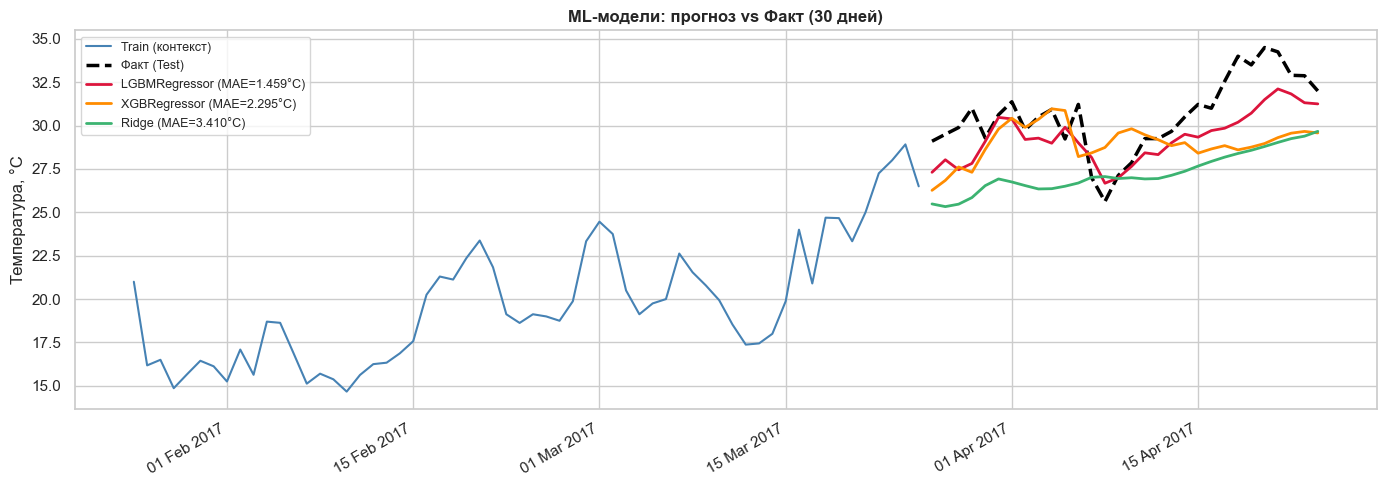

In [156]:
# Визуализация ML прогнозов
ml_model_names = [m.__class__.__name__ for m in ml_models]
colors_ml = ['crimson', 'darkorange', 'mediumseagreen']

plt.figure(figsize=(14, 5))

# Контекст
plt.plot(df_train.tail(60)['ds'], df_train.tail(60)['y'],
         color='steelblue', linewidth=1.5, label='Train (контекст)')
# Факт
plt.plot(forecast_ml_merged['ds'], forecast_ml_merged['actual'],
         color='black', linewidth=2.5, linestyle='--', label='Факт (Test)')

for col, c in zip(ml_model_names, colors_ml):
    if col in forecast_ml_merged.columns:
        mae_val = mean_absolute_error(
            forecast_ml_merged['actual'].dropna(),
            forecast_ml_merged[col].dropna()
        )
        plt.plot(forecast_ml_merged['ds'], forecast_ml_merged[col],
                 color=c, linewidth=2, label=f'{col} (MAE={mae_val:.3f}°C)')

plt.title('ML-модели: прогноз vs Факт (30 дней)', fontweight='bold')
plt.ylabel('Температура, °C')
plt.legend(fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

### 4.3 Важность признаков (LightGBM)

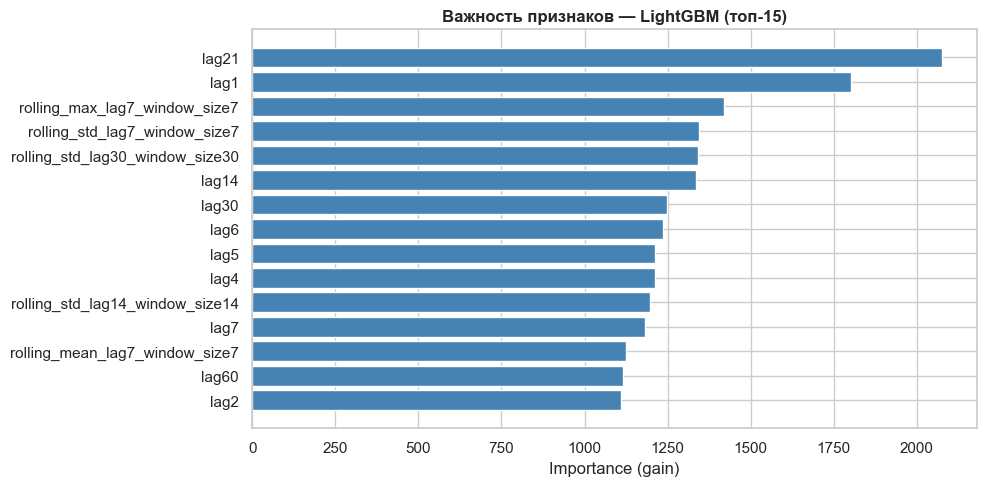

Топ-5 важных признаков:
                        feature  importance
rolling_std_lag30_window_size30        1340
  rolling_std_lag7_window_size7        1343
  rolling_max_lag7_window_size7        1420
                           lag1        1801
                          lag21        2077


In [157]:
# Извлекаем важность признаков из LightGBM
lgb_model = mlf.models_['LGBMRegressor']
feature_names = mlf.ts.features_order_
importances = lgb_model.feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 5))
plt.barh(feat_df['feature'], feat_df['importance'], color='steelblue')
plt.title('Важность признаков — LightGBM (топ-15)', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('Топ-5 важных признаков:')
print(feat_df.tail(5)[['feature', 'importance']].to_string(index=False))

---
# БЛОК 3: DL-методы прогнозирования (neuralforecast)

### Обоснование моделей:

| Модель | Архитектура | Обоснование выбора |
|--------|------------|--------------------|
| **NHITS** | MLP + иерархическая интерполяция | Лучшая точность среди non-transformer моделей на длинных горизонтах; эффективен при наличии сезонности |
| **NBEATS** | Стек блоков с базовыми разложениями | Интерпретируемость: явно разделяет тренд и сезонность; победитель M4-соревнования |
| **LSTM** | Рекуррентная сеть | Классический выбор для временных рядов; хорошо захватывает долгосрочные зависимости |

**Общие параметры:**
- `input_size = 2 × HORIZON = 60` — контекстное окно: 2 горизонта, что обычно оптимально
- `max_steps = 300` — баланс между качеством и временем обучения на CPU
- `loss = MAE` — согласуется с основной метрикой задачи

In [158]:
INPUT_SIZE = 2 * HORIZON  # 60 дней контекста

dl_models = [
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=1500,
        loss=NF_MAE(),
        scaler_type='standard',
        random_seed=SEED,
    ),
    NBEATS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=1500,
        loss=NF_MAE(),
        scaler_type='standard',
        random_seed=SEED,
    ),
    LSTM(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=1500,
        loss=NF_MAE(),
        scaler_type='standard',
        random_seed=SEED,
    ),
]

nf = NeuralForecast(models=dl_models, freq='D')

print('NeuralForecast инициализирован. Модели:')
for m in dl_models:
    print(f'  - {m.__class__.__name__}')

Seed set to 42
Seed set to 42
Seed set to 42


NeuralForecast инициализирован. Модели:
  - NHITS
  - NBEATS
  - LSTM


### 5.1 Бектестинг DL-моделей

In [159]:
# Кросс-валидация DL
cv_dl = nf.cross_validation(
    df=df_train,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    val_size=HORIZON,
)

print(f'CV DL результат: {cv_dl.shape}')
cv_dl.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.5 M  | train | 0    
---------------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
10.184    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 11.47it/s, v_num=66, train_loss_step=0.047, train_loss_epoch=0.047, valid_loss=2.470]  

`Trainer.fit` stopped: `max_steps=1500` reached.


Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 11.01it/s, v_num=66, train_loss_step=0.047, train_loss_epoch=0.047, valid_loss=2.470]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

`Trainer.fit` stopped: `max_steps=1500` reached.


Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 12.89it/s, v_num=70, train_loss_step=0.207, train_loss_epoch=0.207, valid_loss=2.580]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 177.30it/s]
CV DL результат: (90, 7)


,unique_id,ds,cutoff,NHITS,NBEATS,LSTM,y
0,Delhi_Temperature,2016-12-26,2016-12-25,14.750902,13.867906,15.623938,17.142857
1,Delhi_Temperature,2016-12-27,2016-12-25,14.676982,13.384480,14.509768,16.850000
2,Delhi_Temperature,2016-12-28,2016-12-25,13.820572,12.125082,14.178144,17.217391
3,Delhi_Temperature,2016-12-29,2016-12-25,13.820246,12.010172,14.224874,15.238095
4,Delhi_Temperature,2016-12-30,2016-12-25,14.195859,12.057845,14.444908,14.095238


### 5.2 Hold-out прогноз DL

In [160]:
# Обучение на полном train, прогноз на 30 дней
nf.fit(df_train)
forecast_dl = nf.predict()

# Объединяем с реальными значениями
forecast_dl = forecast_dl.reset_index()

forecast_dl['unique_id'] = df_train['unique_id'].iloc[0]

forecast_dl_merged = forecast_dl.merge(
    df_test[['unique_id', 'ds', 'y']].rename(columns={'y': 'actual'}),
    on=['unique_id', 'ds'],
    how='left'
)
print('Прогноз DL выполнен!')
forecast_dl_merged.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.5 M  | train | 0    
---------------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
10.184    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 13.01it/s, v_num=72, train_loss_step=0.0171, train_loss_epoch=0.0171]

`Trainer.fit` stopped: `max_steps=1500` reached.


Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 12.51it/s, v_num=72, train_loss_step=0.0171, train_loss_epoch=0.0171]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.6 M  | train | 0    
---------------------------------------------------------------
2.6 M     Trainable params
5.5 K     Non-trainable params
2.6 M     Total params
10.287    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | hist_encoder | LSTM          | 199 K  | train | 0    
4 | mlp_decoder  | MLP           | 16.6 K | train | 0    
---------------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 K     Total params
0.863     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops



Epoch 1499: 100%|██████████| 1/1 [00:00<00:00, 14.19it/s, v_num=74, train_loss_step=0.0885, train_loss_epoch=0.0885]

`Trainer.fit` stopped: `max_steps=1500` reached.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 241.11it/s]
Прогноз DL выполнен!


,index,unique_id,ds,NHITS,NBEATS,LSTM,actual
0,0,Delhi_Temperature,2017-03-26,24.294779,23.558674,24.578447,29.100000
1,1,Delhi_Temperature,2017-03-27,23.354778,24.886551,24.748798,29.500000
2,2,Delhi_Temperature,2017-03-28,25.905651,25.820475,27.101982,29.888889
3,3,Delhi_Temperature,2017-03-29,24.801441,26.384676,28.293753,31.000000
4,4,Delhi_Temperature,2017-03-30,27.516850,27.458059,24.948765,29.285714


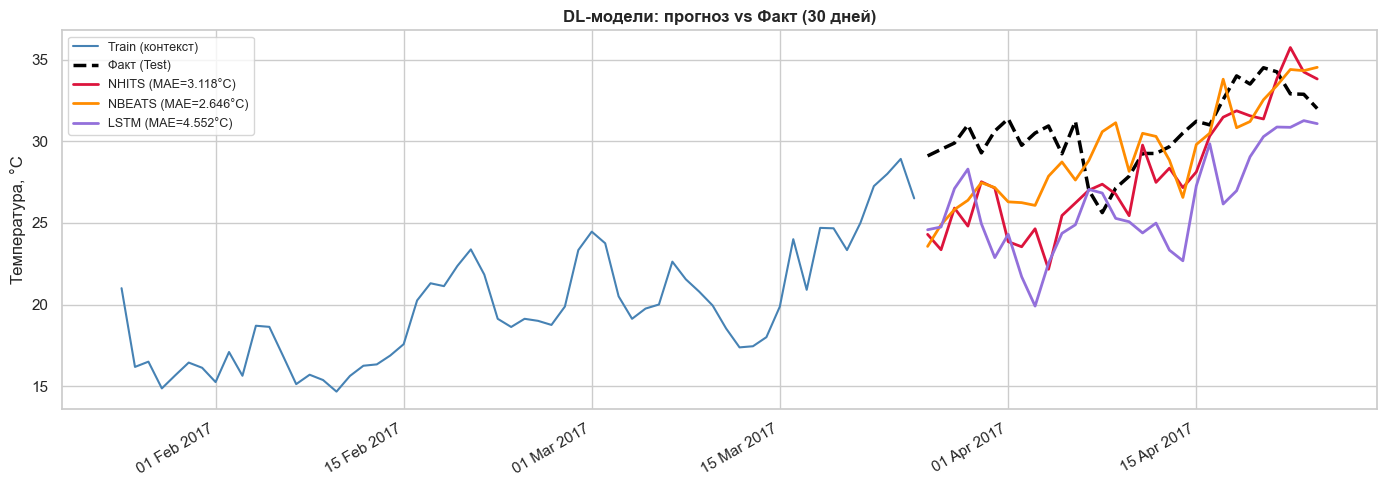

In [161]:
# Визуализация DL прогнозов
dl_model_names = [m.__class__.__name__ for m in dl_models]
colors_dl = ['crimson', 'darkorange', 'mediumpurple']

plt.figure(figsize=(14, 5))
plt.plot(df_train.tail(60)['ds'], df_train.tail(60)['y'],
         color='steelblue', linewidth=1.5, label='Train (контекст)')
plt.plot(forecast_dl_merged['ds'], forecast_dl_merged['actual'],
         color='black', linewidth=2.5, linestyle='--', label='Факт (Test)')

for col, c in zip(dl_model_names, colors_dl):
    if col in forecast_dl_merged.columns:
        mae_val = mean_absolute_error(
            forecast_dl_merged['actual'].dropna(),
            forecast_dl_merged[col].dropna()
        )
        plt.plot(forecast_dl_merged['ds'], forecast_dl_merged[col],
                 color=c, linewidth=2, label=f'{col} (MAE={mae_val:.3f}°C)')

plt.title('DL-модели: прогноз vs Факт (30 дней)', fontweight='bold')
plt.ylabel('Температура, °C')
plt.legend(fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

---
# БЛОК 4: Итоговое сравнение всех методов

In [162]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def get_metrics(merged_df, model_col, actual_col='actual'):
    valid = merged_df[[actual_col, model_col]].dropna()
    mae_val  = mean_absolute_error(valid[actual_col], valid[model_col])
    rmse_val = rmse(valid[actual_col], valid[model_col])
    return round(mae_val, 4), round(rmse_val, 4)

def get_cv_metrics(cv_df, model_col, actual_col='y'):
    valid = cv_df[[actual_col, model_col]].dropna()
    mae_val  = mean_absolute_error(valid[actual_col], valid[model_col])
    rmse_val = rmse(valid[actual_col], valid[model_col])
    return round(mae_val, 4), round(rmse_val, 4)

results = []

# Бейзлайн из Задачи №2
results.append({
    'Модель': 'MSTL (бейзлайн)', 'Тип': 'Статистика',
    'MAE (CV)': 2.8869, 'RMSE (CV)': 3.4313,
    'MAE (Test)': 2.0541, 'RMSE (Test)': 2.4171
})

# ML
cv_ml_reset = cv_ml.reset_index()
for col in ml_model_names:
    if col in forecast_ml_merged.columns:
        cv_mae, cv_rmse   = get_cv_metrics(cv_ml_reset, col)
        test_mae, test_rmse = get_metrics(forecast_ml_merged, col)
        results.append({
            'Модель': col, 'Тип': 'ML',
            'MAE (CV)': cv_mae, 'RMSE (CV)': cv_rmse,
            'MAE (Test)': test_mae, 'RMSE (Test)': test_rmse
        })

# DL
cv_dl_reset = cv_dl.reset_index()
for col in dl_model_names:
    if col in forecast_dl_merged.columns:
        cv_mae, cv_rmse   = get_cv_metrics(cv_dl_reset, col)
        test_mae, test_rmse = get_metrics(forecast_dl_merged, col)
        results.append({
            'Модель': col, 'Тип': 'DL',
            'MAE (CV)': cv_mae, 'RMSE (CV)': cv_rmse,
            'MAE (Test)': test_mae, 'RMSE (Test)': test_rmse
        })

results_df = pd.DataFrame(results).sort_values('MAE (Test)')

print('=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МЕТОДОВ ===')
print(results_df.to_string(index=False))

=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МЕТОДОВ ===
         Модель        Тип  MAE (CV)  RMSE (CV)  MAE (Test)  RMSE (Test)
  LGBMRegressor         ML    2.4777     2.9500      1.4586       1.7448
MSTL (бейзлайн) Статистика    2.8869     3.4313      2.0541       2.4171
   XGBRegressor         ML    2.5801     3.0919      2.2950       2.7889
         NBEATS         DL    2.8686     3.6139      2.6459       3.0712
          NHITS         DL    2.6178     3.3685      3.1183       3.8498
          Ridge         ML    2.4352     3.0099      3.4101       3.7091
           LSTM         DL    2.7810     3.7387      4.5518       5.2238


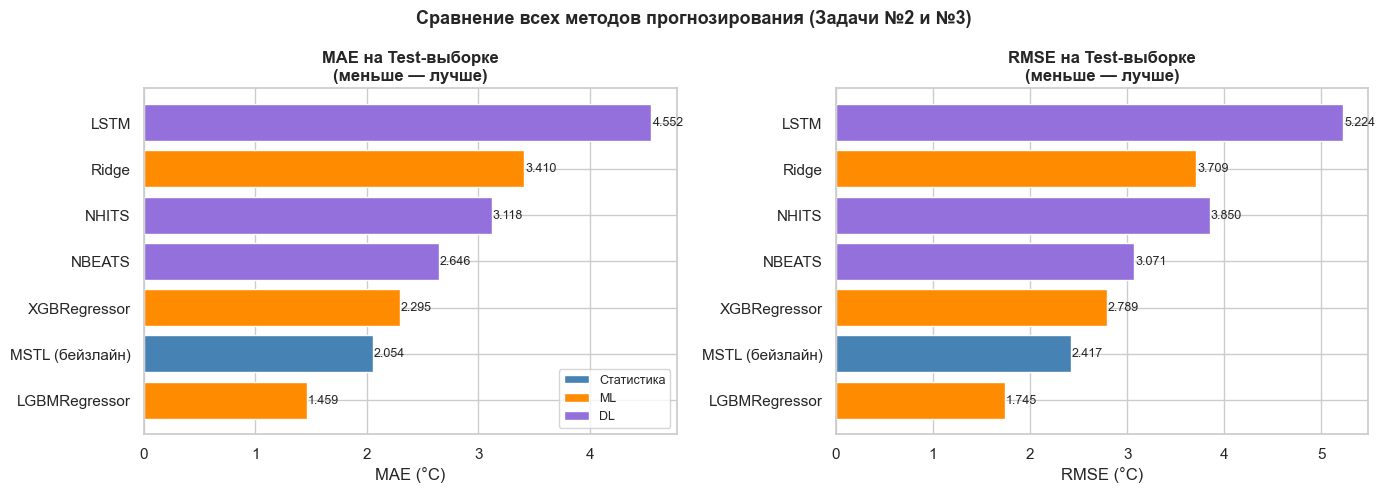

In [163]:
# Визуальное сравнение
palette = {'Статистика': 'steelblue', 'ML': 'darkorange', 'DL': 'mediumpurple'}
bar_colors = [palette[t] for t in results_df['Тип']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Модель'], results_df['MAE (Test)'], color=bar_colors)
axes[0].set_title('MAE на Test-выборке\n(меньше — лучше)', fontweight='bold')
axes[0].set_xlabel('MAE (°C)')
for i, v in enumerate(results_df['MAE (Test)']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(results_df['Модель'], results_df['RMSE (Test)'], color=bar_colors)
axes[1].set_title('RMSE на Test-выборке\n(меньше — лучше)', fontweight='bold')
axes[1].set_xlabel('RMSE (°C)')
for i, v in enumerate(results_df['RMSE (Test)']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Легенда по типам
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in palette.items()]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('Сравнение всех методов прогнозирования (Задачи №2 и №3)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [164]:
# Сохранение результатов
results_df.to_csv('Task3_Comparison_Table.csv', index=False)

print('Файлы сохранены:')
print('  Task3_Comparison_Table.csv — итоговая таблица всех методов')

best = results_df.iloc[0]
baseline_mae = 2.0541
improvement = (baseline_mae - best['MAE (Test)']) / baseline_mae * 100

print(f'\nЛучшая модель: {best["Модель"]} ({best["Тип"]})')
print(f'  MAE (Test):  {best["MAE (Test)"]} °C')
print(f'  RMSE (Test): {best["RMSE (Test)"]} °C')
print(f'  Улучшение vs MSTL-бейзлайн: {improvement:+.1f}%')

Файлы сохранены:
  Task3_Comparison_Table.csv — итоговая таблица всех методов

Лучшая модель: LGBMRegressor (ML)
  MAE (Test):  1.4586 °C
  RMSE (Test): 1.7448 °C
  Улучшение vs MSTL-бейзлайн: +29.0%


## Выводы по Задаче №3

*(Выводы заполняются после получения числовых результатов)*

**Аномалии:**
- IQR — простейший метод, хорошо работает для явных глобальных выбросов по амплитуде (как аномалия давления из Задачи №1).
- Isolation Forest — учитывает контекст через лаговые признаки, находит локально аномальные паттерны, не видимые по абсолютному значению.
- DBSCAN — обнаруживает аномалии через плотность соседей; чувствителен к параметру eps, требует подбора через k-distance график.

**ML vs DL vs Статистика:**
- ML-модели за счёт лаговых и календарных признаков могут явно использовать сезонную структуру и внешние факторы.
- DL-модели (NHITS, NBEATS) исторически выигрывают при больших объёмах данных; на 1500 наблюдениях преимущество неочевидно.
- NBEATS интерпретируем: явно выделяет трендовую и сезонную компоненту.
- Статистический MSTL остаётся сильным конкурентом для хорошо структурированных сезонных рядов.